# Handeling Data

## Load data and quick overview

In [ ]:
# import numpy as np
# print(np.__version__)

1.26.4


In [ ]:
# !pip install scikit-surprise

In [ ]:
# # Downgrade NumPy and reinstall surprise to link against it
# !pip install "numpy<2.0"
# !pip install scikit-surprise

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'the-movies-dataset' dataset.
Path to dataset files: /kaggle/input/the-movies-dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
warnings.filterwarnings('ignore')

In [ ]:
main_path = "/kaggle/input/the-movies-dataset/"
movies_metadata_path = main_path + "movies_metadata.csv"
credits_path = main_path + "credits.csv"
keywords_path = main_path + "keywords.csv"
links_path = main_path + "links_small.csv"
ratings_path = main_path + "ratings_small.csv"

In [ ]:
df = pd.read_csv(movies_metadata_path)
df.head().transpose()

,0,1,2,3,4
adult,False,False,False,False,False
belongs_to_collection,"{'id': 10194, 'name': 'Toy Story Collection', ...",NaN,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",NaN,"{'id': 96871, 'name': 'Father of the Bride Col..."
budget,30000000,65000000,0,16000000,0
genres,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...","[{'id': 35, 'name': 'Comedy'}]"
homepage,http://toystory.disney.com/toy-story,NaN,NaN,NaN,NaN
id,862,8844,15602,31357,11862
imdb_id,tt0114709,tt0113497,tt0113228,tt0114885,tt0113041
original_language,en,en,en,en,en
original_title,Toy Story,Jumanji,Grumpier Old Men,Waiting to Exhale,Father of the Bride Part II
overview,"Led by Woody, Andy's toys live happily in his ...",When siblings Judy and Peter discover an encha...,A family wedding reignites the ancient feud be...,"Cheated on, mistreated and stepped on, the wom...",Just when George Banks has recovered from his ...


In [ ]:
print("Missing values in Train DataFrame:")
missing_df = df.isnull().sum().sort_values(ascending=False)
missing_df_percent = (missing_df / len(df)) * 100
missing_df_info = pd.DataFrame({'Missing Count': missing_df, 'Missing Percentage (%)': missing_df_percent})
display(missing_df_info[missing_df_info['Missing Count'] > 0])

Missing values in Train DataFrame:


,Missing Count,Missing Percentage (%)
belongs_to_collection,40972,90.115691
homepage,37684,82.883913
tagline,25054,55.104914
overview,954,2.098271
poster_path,386,0.848986
runtime,263,0.578454
status,87,0.191352
release_date,87,0.191352
imdb_id,17,0.037391
original_language,11,0.024194


## Missing values

In [ ]:
high_missing_cols = missing_df_info[missing_df_info['Missing Percentage (%)'] > 50].index.tolist()
moderate_missing_cols = missing_df_info[(missing_df_info['Missing Percentage (%)'] <= 50) & (missing_df_info['Missing Percentage (%)'] > 1)].index.tolist()
low_missing_cols = missing_df_info[missing_df_info['Missing Percentage (%)'] <= 1].index.tolist()

print("Columns with high missing percentage (>50%):", high_missing_cols)
print("Columns with moderate missing percentage (1%-50%):", moderate_missing_cols)
print("Columns with low missing percentage (<=1%):", low_missing_cols)

handling_strategy = {}

for col in high_missing_cols:
    handling_strategy[col] = "Drop column due to high missing percentage"

if 'overview' in moderate_missing_cols:
    handling_strategy['overview'] = "Consider dropping or using a placeholder for text data"

numerical_low_missing = ['runtime', 'vote_average', 'vote_count', 'revenue', 'popularity']
for col in low_missing_cols:
    if col in numerical_low_missing:
        handling_strategy[col] = "Impute with mean or median"
    elif col in ['status', 'release_date', 'imdb_id', 'original_language', 'title', 'video', 'spoken_languages', 'production_countries', 'production_companies', 'poster_path']:
         handling_strategy[col] = "Consider imputation (e.g., mode, placeholder) or dropping rows"


handling_strategy['adult'] = "Investigate and potentially remove incorrect entries (e.g., 'R')"


print("\nIdentified Handling Strategy for each column with missing values:")
for col, strategy in handling_strategy.items():
    print(f"- {col}: {strategy}")

Columns with high missing percentage (>50%): ['belongs_to_collection', 'homepage', 'tagline']
Columns with moderate missing percentage (1%-50%): ['overview']
Columns with low missing percentage (<=1%): ['poster_path', 'runtime', 'status', 'release_date', 'imdb_id', 'original_language', 'spoken_languages', 'title', 'video', 'vote_average', 'revenue', 'vote_count', 'popularity', 'production_companies', 'production_countries', 'original_title', 'id', 'genres', 'budget', 'adult']

Identified Handling Strategy for each column with missing values:
- belongs_to_collection: Drop column due to high missing percentage
- homepage: Drop column due to high missing percentage
- tagline: Drop column due to high missing percentage
- overview: Consider dropping or using a placeholder for text data
- poster_path: Consider imputation (e.g., mode, placeholder) or dropping rows
- runtime: Impute with mean or median
- status: Consider imputation (e.g., mode, placeholder) or dropping rows
- release_date: Con

In [ ]:
cols_to_drop = ['belongs_to_collection', 'homepage', 'tagline']
df = df.drop(columns=cols_to_drop)

df['overview'] = df['overview'].fillna('No overview available')

print(df['popularity'].dtype)
print(df['popularity'].unique())

df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

numerical_cols_to_impute = ['runtime', 'vote_average', 'vote_count', 'revenue', 'popularity']
for col in numerical_cols_to_impute:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

remaining_missing_cols = df.columns[df.isnull().any()].tolist()
cols_to_fill_unknown = [col for col in remaining_missing_cols if col not in numerical_cols_to_impute and col != 'adult']

for col in cols_to_fill_unknown:
    df[col] = df[col].fillna('Unknown')

df = df[df['adult'].isin(['True', 'False'])]

print("Missing values after handling:")
display(df.isnull().sum().sort_values(ascending=False))

object
[21.946943 17.015539 11.7129 ... '0.903007' '0.003503' '0.163015']
Missing values after handling:


,0
adult,0
production_countries,0
vote_average,0
video,0
title,0
status,0
spoken_languages,0
runtime,0
revenue,0
release_date,0


In [ ]:
credits_df = pd.read_csv(credits_path)
keywords_df = pd.read_csv(keywords_path)
links_df = pd.read_csv(links_path)
ratings_df = pd.read_csv(ratings_path)

In [ ]:
credits_df.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [ ]:
keywords_df.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [ ]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [ ]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
print("Missing values in 'id' column of df:", df['id'].isnull().sum())
print("Missing values in 'id' column of credits_df:", credits_df['id'].isnull().sum())
print("Missing values in 'id' column of keywords_df:", keywords_df['id'].isnull().sum())
print("Missing values in 'tmdbId' column of links_df:", links_df['tmdbId'].isnull().sum())
print("Missing values in 'movieId' column of links_df:", links_df['movieId'].isnull().sum())
print("Missing values in 'movieId' column of ratings_df:", ratings_df['movieId'].isnull().sum())

Missing values in 'id' column of df: 0
Missing values in 'id' column of credits_df: 0
Missing values in 'id' column of keywords_df: 0
Missing values in 'tmdbId' column of links_df: 13
Missing values in 'movieId' column of links_df: 0
Missing values in 'movieId' column of ratings_df: 0


In [ ]:
print("Data type of 'id' in df:", df['id'].dtype)
print("Data type of 'id' in credits_df:", credits_df['id'].dtype)
print("Data type of 'id' in keywords_df:", keywords_df['id'].dtype)
print("Data type of 'tmdbId' in links_df:", links_df['tmdbId'].dtype)
print("Data type of 'movieId' in links_df:", links_df['movieId'].dtype)
print("Data type of 'movieId' in ratings_df:", ratings_df['movieId'].dtype)

Data type of 'id' in df: object
Data type of 'id' in credits_df: int64
Data type of 'id' in keywords_df: int64
Data type of 'tmdbId' in links_df: float64
Data type of 'movieId' in links_df: int64
Data type of 'movieId' in ratings_df: int64


In [ ]:
df['id'] = pd.to_numeric(df['id'], errors='coerce')
df.dropna(subset=['id'], inplace=True)
df['id'] = df['id'].astype(int)

links_df.dropna(subset=['tmdbId'], inplace=True)
links_df['tmdbId'] = links_df['tmdbId'].astype(int)

print("Updated data type of 'id' in df:", df['id'].dtype)
print("Updated data type of 'tmdbId' in links_df:", links_df['tmdbId'].dtype)

Updated data type of 'id' in df: int64
Updated data type of 'tmdbId' in links_df: int64


## Handling jsons

In [ ]:
import json

def is_json_like(value):
    """Checks if a string value is likely a JSON array or object."""
    if isinstance(value, str):
        value = value.strip()
        if (value.startswith('[') and value.endswith(']')) or \
           (value.startswith('{') and value.endswith('}')):
            try:
                json.loads(value)
                return True
            except json.JSONDecodeError:
                pass
    return False

json_columns = []
for col in df.columns:
    sample_values = df[col].dropna().sample(min(100, len(df[col].dropna())))
    if any(sample_values.apply(is_json_like)):
        json_columns.append(col)

print("Columns that appear to contain JSON format:", json_columns)

Columns that appear to contain JSON format: ['production_companies', 'production_countries', 'spoken_languages']


In [ ]:
copy_df = df.copy()

In [ ]:
import ast
import numpy as np

def extract_names_and_handle_empty(json_list_string):
    """Extracts names from a string representation of a list of dictionaries and handles empty lists as NaN."""
    if isinstance(json_list_string, str) and json_list_string.startswith('[') and json_list_string.endswith(']'):
        try:
            data_list = ast.literal_eval(json_list_string)
            if isinstance(data_list, list):
                if not data_list:
                    return np.nan
                names = [item.get('name', '') for item in data_list if isinstance(item, dict) and 'name' in item]
                return ', '.join(names)
        except (ValueError, SyntaxError):
            pass
    return ''

json_columns = ['genres', 'production_companies', 'production_countries', 'spoken_languages']

for col in json_columns:
    if col in copy_df.columns:
        copy_df[col] = copy_df[col].apply(extract_names_and_handle_empty)
        copy_df[col] = copy_df[col].fillna('Unknown')

In [ ]:
parsed_json_columns = ['genres', 'production_companies', 'production_countries', 'spoken_languages']

print("Count and percentage of 'Unknown' values in parsed JSON columns:")
for col in parsed_json_columns:
    if col in copy_df.columns:
        unknown_count = (copy_df[col] == 'Unknown').sum()
        total_count = len(copy_df[col])
        unknown_percentage = (unknown_count / total_count) * 100 if total_count > 0 else 0
        print(f"- {col}: {unknown_count} ('Unknown' values) out of {total_count} (Total values) - {unknown_percentage:.2f}%")

Count and percentage of 'Unknown' values in parsed JSON columns:
- genres: 2442 ('Unknown' values) out of 45463 (Total values) - 5.37%
- production_companies: 11875 ('Unknown' values) out of 45463 (Total values) - 26.12%
- production_countries: 6282 ('Unknown' values) out of 45463 (Total values) - 13.82%
- spoken_languages: 3829 ('Unknown' values) out of 45463 (Total values) - 8.42%


In [ ]:
df = copy_df.copy()

In [ ]:
import json

def is_json_like(value):
    """Checks if a string value is likely a JSON array or object."""
    if isinstance(value, str):
        value = value.strip()
        if (value.startswith('[') and value.endswith(']')) or \
           (value.startswith('{') and value.endswith('}')):
            try:
                json.loads(value)
                return True
            except json.JSONDecodeError:
                pass
    return False

json_columns_credits = []
for col in credits_df.columns:
    sample_values = credits_df[col].dropna().sample(min(100, len(credits_df[col].dropna())))
    if any(sample_values.apply(is_json_like)):
        json_columns_credits.append(col)

print("Columns in credits_df that appear to contain JSON format:", json_columns_credits)

json_columns_keywords = []
for col in keywords_df.columns:

    sample_values = keywords_df[col].dropna().sample(min(100, len(keywords_df[col].dropna())))
    if any(sample_values.apply(is_json_like)):
        json_columns_keywords.append(col)

print("Columns in keywords_df that appear to contain JSON format:", json_columns_keywords)

Columns in credits_df that appear to contain JSON format: ['cast', 'crew']
Columns in keywords_df that appear to contain JSON format: ['keywords']


In [ ]:
import ast
import numpy as np

def extract_names_from_list(json_list_string, key='name'):
    """Extracts values for a given key from a string representation of a list of dictionaries and handles empty lists as NaN."""
    if isinstance(json_list_string, str) and json_list_string.startswith('[') and json_list_string.endswith(']'):
        try:
            data_list = ast.literal_eval(json_list_string)
            if isinstance(data_list, list):
                if not data_list:  # Check if the list is empty
                    return np.nan  # Replace empty list with NaN
                names = [item.get(key, '') for item in data_list if isinstance(item, dict) and key in item]
                return ', '.join(names)
        except (ValueError, SyntaxError):
            pass
    return ''

credits_df['cast'] = credits_df['cast'].apply(extract_names_from_list, key='name')
credits_df['crew'] = credits_df['crew'].apply(extract_names_from_list, key='name')

credits_df['cast'] = credits_df['cast'].fillna('Unknown')
credits_df['crew'] = credits_df['crew'].fillna('Unknown')

keywords_df['keywords'] = keywords_df['keywords'].apply(extract_names_from_list, key='name')

keywords_df['keywords'] = keywords_df['keywords'].fillna('Unknown')


print("credits_df after parsing and handling empty lists:")
display(credits_df.head())

print("\nkeywords_df after parsing and handling empty lists:")
display(keywords_df.head())

credits_df after parsing and handling empty lists:


,cast,crew,id
0,"Tom Hanks, Tim Allen, Don Rickles, Jim Varney,...","John Lasseter, Joss Whedon, Andrew Stanton, Jo...",862
1,"Robin Williams, Jonathan Hyde, Kirsten Dunst, ...","Larry J. Franco, Jonathan Hensleigh, James Hor...",8844
2,"Walter Matthau, Jack Lemmon, Ann-Margret, Soph...","Howard Deutch, Mark Steven Johnson, Mark Steve...",15602
3,"Whitney Houston, Angela Bassett, Loretta Devin...","Forest Whitaker, Ronald Bass, Ronald Bass, Ezr...",31357
4,"Steve Martin, Diane Keaton, Martin Short, Kimb...","Alan Silvestri, Elliot Davis, Nancy Meyers, Na...",11862



keywords_df after parsing and handling empty lists:


,id,keywords
0,862,"jealousy, toy, boy, friendship, friends, rival..."
1,8844,"board game, disappearance, based on children's..."
2,15602,"fishing, best friend, duringcreditsstinger, ol..."
3,31357,"based on novel, interracial relationship, sing..."
4,11862,"baby, midlife crisis, confidence, aging, daugh..."


In [ ]:
parsed_credits_columns = ['cast', 'crew']
parsed_keywords_columns = ['keywords']

print("Count and percentage of 'Unknown' values in parsed credits_df columns:")
for col in parsed_credits_columns:
    if col in credits_df.columns:
        unknown_count = (credits_df[col] == 'Unknown').sum()
        total_count = len(credits_df[col])
        unknown_percentage = (unknown_count / total_count) * 100 if total_count > 0 else 0
        print(f"- {col}: {unknown_count} ('Unknown' values) out of {total_count} (Total values) - {unknown_percentage:.2f}%")

print("\nCount and percentage of 'Unknown' values in parsed keywords_df columns:")
for col in parsed_keywords_columns:
    if col in keywords_df.columns:
        unknown_count = (keywords_df[col] == 'Unknown').sum()
        total_count = len(keywords_df[col])
        unknown_percentage = (unknown_count / total_count) * 100 if total_count > 0 else 0
        print(f"- {col}: {unknown_count} ('Unknown' values) out of {total_count} (Total values) - {unknown_percentage:.2f}%")

Count and percentage of 'Unknown' values in parsed credits_df columns:
- cast: 2418 ('Unknown' values) out of 45476 (Total values) - 5.32%
- crew: 771 ('Unknown' values) out of 45476 (Total values) - 1.70%

Count and percentage of 'Unknown' values in parsed keywords_df columns:
- keywords: 14795 ('Unknown' values) out of 46419 (Total values) - 31.87%


## Handling duplicates

In [ ]:
print("Duplicates in 'id' column of df:", df['id'].duplicated().sum())
print("Duplicates in 'id' column of credits_df:", credits_df['id'].duplicated().sum())
print("Duplicates in 'id' column of keywords_df:", keywords_df['id'].duplicated().sum())
print("Duplicates in 'tmdbId' column of links_df:", links_df['tmdbId'].duplicated().sum())
print("Duplicates in 'movieId' column of links_df:", links_df['movieId'].duplicated().sum())
print("Duplicates in 'imbdId' column of links_df:", links_df['imdbId'].duplicated().sum())
print("Duplicates in 'movieId' column of ratings_df:", ratings_df.duplicated(subset=['movieId', 'userId']).sum())

Duplicates in 'id' column of df: 30
Duplicates in 'id' column of credits_df: 44
Duplicates in 'id' column of keywords_df: 987
Duplicates in 'tmdbId' column of links_df: 0
Duplicates in 'movieId' column of links_df: 0
Duplicates in 'imbdId' column of links_df: 0
Duplicates in 'movieId' column of ratings_df: 0


In [ ]:
df.drop_duplicates(subset=['id'], inplace=True)
credits_df.drop_duplicates(subset=['id'], inplace=True)
keywords_df.drop_duplicates(subset=['id'], inplace=True)
links_df.drop_duplicates(subset=['tmdbId'], inplace=True)
ratings_df.drop_duplicates(subset=['movieId', 'userId'], inplace=True)

print("Duplicates in 'id' column of df after removal:", df['id'].duplicated().sum())
print("Duplicates in 'id' column of credits_df after removal:", credits_df['id'].duplicated().sum())
print("Duplicates in 'id' column of keywords_df after removal:", keywords_df['id'].duplicated().sum())
print("Duplicates in 'tmdbId' column of links_df after removal:", links_df['tmdbId'].duplicated().sum())
print("Duplicates in 'movieId' column of links_df after removal:", links_df['movieId'].duplicated().sum())
print("Duplicates in 'movieId' column of ratings_df after removal:", ratings_df.duplicated(subset=['movieId', 'userId']).sum())

Duplicates in 'id' column of df after removal: 0
Duplicates in 'id' column of credits_df after removal: 0
Duplicates in 'id' column of keywords_df after removal: 0
Duplicates in 'tmdbId' column of links_df after removal: 0
Duplicates in 'movieId' column of links_df after removal: 0
Duplicates in 'movieId' column of ratings_df after removal: 0


In [ ]:
print("Shape of df:", df.shape)
print("Shape of credits_df:", credits_df.shape)
print("Shape of keywords_df:", keywords_df.shape)
print("Shape of links_df:", links_df.shape)
print("Shape of ratings_df:", ratings_df.shape)

Shape of df: (45433, 21)
Shape of credits_df: (45432, 3)
Shape of keywords_df: (45432, 2)
Shape of links_df: (9112, 3)
Shape of ratings_df: (100004, 4)


## Merging dataframes

In [ ]:
merged_df = pd.merge(df, credits_df, on='id', how='inner')
merged_df = pd.merge(merged_df, keywords_df, on='id', how='inner')
merged_df = pd.merge(merged_df, links_df, left_on='id', right_on='tmdbId', how='inner')
merged_df = pd.merge(merged_df, ratings_df, on='movieId', how='inner')

print("Shape of the merged dataframe:", merged_df.shape)
display(merged_df.head().transpose())

Shape of the merged dataframe: (99810, 30)


,0,1,2,3,4
adult,False,False,False,False,False
budget,30000000,30000000,30000000,30000000,30000000
genres,"Animation, Comedy, Family","Animation, Comedy, Family","Animation, Comedy, Family","Animation, Comedy, Family","Animation, Comedy, Family"
id,862,862,862,862,862
imdb_id,tt0114709,tt0114709,tt0114709,tt0114709,tt0114709
original_language,en,en,en,en,en
original_title,Toy Story,Toy Story,Toy Story,Toy Story,Toy Story
overview,"Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ..."
popularity,21.946943,21.946943,21.946943,21.946943,21.946943
poster_path,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg


# Feature engineering

## Choosing appropiate features

In [ ]:
# Drop redundant ID columns
merged_df = merged_df.drop(columns=['id', 'tmdbId', 'imdbId', 'imdb_id', 'original_title', 'video'])

# Define the desired column order
desired_column_order = [
    'movieId',
    'title',
    'release_date',
    'runtime',
    'status',
    'adult',
    'budget',
    'revenue',
    'popularity',
    'vote_average',
    'vote_count',
    'overview',
    'genres',
    'keywords',
    'cast',
    'crew',
    'production_companies',
    'production_countries',
    'original_language',
    'userId',
    'rating',
]

merged_df = merged_df.reindex(columns=desired_column_order)

print("Shape of merged_df after dropping columns and reordering:", merged_df.shape)
display(merged_df.head().transpose())

Shape of merged_df after dropping columns and reordering: (99810, 21)


,0,1,2,3,4
movieId,1,1,1,1,1
title,Toy Story,Toy Story,Toy Story,Toy Story,Toy Story
release_date,1995-10-30,1995-10-30,1995-10-30,1995-10-30,1995-10-30
runtime,81.0,81.0,81.0,81.0,81.0
status,Released,Released,Released,Released,Released
adult,False,False,False,False,False
budget,30000000,30000000,30000000,30000000,30000000
revenue,373554033.0,373554033.0,373554033.0,373554033.0,373554033.0
popularity,21.946943,21.946943,21.946943,21.946943,21.946943
vote_average,7.7,7.7,7.7,7.7,7.7


In [ ]:
merged_df['budget'] = pd.to_numeric(merged_df['budget'], errors='coerce').fillna(0)
merged_df['revenue'] = pd.to_numeric(merged_df['revenue'], errors='coerce').fillna(0)
merged_df = merged_df[merged_df['runtime'] > 0]
merged_df = merged_df[merged_df['budget'] >= 0]
merged_df = merged_df[merged_df['revenue'] >= 0]
# Remove extreme outliers (top 0.5% for budget/revenue)
for col in ['budget', 'revenue']:
  upper = merged_df[col].quantile(0.995)
  merged_df = merged_df[merged_df[col] <= upper]

In [ ]:
merged_df['budget'] = pd.to_numeric(merged_df['budget'], errors='coerce').fillna(0)
merged_df['revenue'] = pd.to_numeric(merged_df['revenue'], errors='coerce').fillna(0)
merged_df['budget_to_revenue_ratio'] = merged_df.apply(lambda row: row['budget'] / row['revenue'] if row['revenue'] > 0 else 0, axis=1)

In [ ]:
top_n = 5

In [ ]:
genre_dummies = merged_df['genres'].str.get_dummies(sep=', ')
top_genres = genre_dummies.sum().sort_values(ascending=False).head(top_n).index
for genre in top_genres:
  merged_df[f"genre_{genre}"] = genre_dummies[genre]

In [ ]:
top_genres

Index(['Drama', 'Comedy', 'Thriller', 'Action', 'Adventure'], dtype='object')

In [ ]:
for col in ['budget', 'revenue', 'popularity', 'vote_count']:
            merged_df[f'log_{col}'] = np.log1p(merged_df[col])

In [ ]:
merged_df.shape

(98845, 31)

In [ ]:
merged_df['budget_x_popularity'] = merged_df['budget'] * merged_df['popularity']
merged_df['budget_x_vote_count'] = merged_df['budget'] * merged_df['vote_count']

In [ ]:
merged_df['num_genres'] = merged_df['genres'].fillna('').apply(lambda x: len([g for g in x.split(',') if g.strip()]))
merged_df['num_keywords'] = merged_df['keywords'].fillna('').apply(lambda x: len([k for k in x.split(',') if k.strip()]))
merged_df['num_cast'] = merged_df['cast'].fillna('').apply(lambda x: len([c for c in x.split(',') if c.strip()]))
merged_df['num_crew'] = merged_df['crew'].fillna('').apply(lambda x: len([c for c in x.split(',') if c.strip()]))

In [ ]:
merged_df['release_date'] = pd.to_datetime(merged_df['release_date'], errors='coerce')
merged_df['release_year'] = merged_df['release_date'].dt.year

In [ ]:
merged_df.drop(columns=['release_date'], inplace=True)

In [ ]:
if 'adult' in merged_df.columns:
    merged_df['is_adult'] = merged_df['adult'].map({'True': 1, 'False': 0})

In [ ]:
merged_df.drop(columns=['adult'], inplace=True)

In [ ]:
merged_df.shape

(98845, 37)

## Top n's

In [ ]:
keywords_split = merged_df['keywords'].fillna('').apply(lambda x: [k.strip() for k in x.split(',') if k.strip()])
mlb = MultiLabelBinarizer()
top_keywords = pd.Series([k for sublist in keywords_split for k in sublist]).value_counts().head(top_n).index
keywords_filtered = keywords_split.apply(lambda x: [k for k in x if k in top_keywords])
keyword_dummies = pd.DataFrame(mlb.fit_transform(keywords_filtered), columns=[f'kw_{k}' for k in mlb.classes_], index=merged_df.index)
merged_df = pd.concat([merged_df, keyword_dummies], axis=1)

In [ ]:
top_n_cast=5
top_n_crew=5
cast_split = merged_df['cast'].fillna('').apply(lambda x: [c.strip() for c in x.split(',') if c.strip()])
crew_split = merged_df['crew'].fillna('').apply(lambda x: [c.strip() for c in x.split(',') if c.strip()])
mlb_cast = MultiLabelBinarizer()
mlb_crew = MultiLabelBinarizer()
top_cast = pd.Series([c for sublist in cast_split for c in sublist]).value_counts().head(top_n_cast).index
top_crew = pd.Series([c for sublist in crew_split for c in sublist]).value_counts().head(top_n_crew).index
cast_filtered = cast_split.apply(lambda x: [c for c in x if c in top_cast])
crew_filtered = crew_split.apply(lambda x: [c for c in x if c in top_crew])
cast_dummies = pd.DataFrame(mlb_cast.fit_transform(cast_filtered), columns=[f'cast_{c}' for c in mlb_cast.classes_], index=merged_df.index)
crew_dummies = pd.DataFrame(mlb_crew.fit_transform(crew_filtered), columns=[f'crew_{c}' for c in mlb_crew.classes_], index=merged_df.index)
merged_df = pd.concat([merged_df, cast_dummies, crew_dummies], axis=1)

In [ ]:
top_n_company=5
top_n_country=5
company_split = merged_df['production_companies'].fillna('').apply(lambda x: [c.strip() for c in x.split(',') if c.strip()])
country_split = merged_df['production_countries'].fillna('').apply(lambda x: [c.strip() for c in x.split(',') if c.strip()])
mlb_company = MultiLabelBinarizer()
mlb_country = MultiLabelBinarizer()
top_company = pd.Series([c for sublist in company_split for c in sublist]).value_counts().head(top_n_company).index
top_country = pd.Series([c for sublist in country_split for c in sublist]).value_counts().head(top_n_country).index
company_filtered = company_split.apply(lambda x: [c for c in x if c in top_company])
country_filtered = country_split.apply(lambda x: [c for c in x if c in top_country])
company_dummies = pd.DataFrame(mlb_company.fit_transform(company_filtered), columns=[f'company_{c}' for c in mlb_company.classes_], index=merged_df.index)
country_dummies = pd.DataFrame(mlb_country.fit_transform(country_filtered), columns=[f'country_{c}' for c in mlb_country.classes_], index=merged_df.index)
merged_df = pd.concat([merged_df, company_dummies, country_dummies], axis=1)

In [ ]:
merged_df = pd.get_dummies(merged_df, columns=['status'], drop_first=False)

In [ ]:
def add_target_encoding(col, target='vote_average', top_n=5):
  values = pd.Series([v for sublist in merged_df[col].fillna('').apply(lambda x: [i.strip() for i in x.split(',') if i.strip()]) for v in sublist])
  top_values = values.value_counts().head(top_n).index
  for v in top_values:
      mask = merged_df[col].str.contains(rf'\b{v}\b', regex=True)
      mean_val = merged_df.loc[mask, target].mean()
      merged_df[f'{col}_{v}_mean_{target}'] = mask.astype(int) * mean_val

In [ ]:
add_target_encoding(col='genres')
add_target_encoding(col='production_companies')

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_overview_vectorizer = TfidfVectorizer(max_features=1900, stop_words='english')
tfidf_overview_matrix = tfidf_overview_vectorizer.fit_transform(merged_df['overview'].fillna(''))
tfidf_overview_df = pd.DataFrame(tfidf_overview_matrix.toarray(), columns=[f'overview_tfidf_{col}' for col in tfidf_overview_vectorizer.get_feature_names_out()], index=merged_df.index)

print("Shape of TF-IDF overview DataFrame:", tfidf_overview_df.shape)

display(tfidf_overview_df.head())

Shape of TF-IDF overview DataFrame: (98845, 1900)


,overview_tfidf_000,overview_tfidf_10,overview_tfidf_12,overview_tfidf_13,overview_tfidf_15,overview_tfidf_1930s,overview_tfidf_1940s,overview_tfidf_1950s,overview_tfidf_1955,overview_tfidf_1985,...,overview_tfidf_wrong,overview_tfidf_wrongfully,overview_tfidf_year,overview_tfidf_years,overview_tfidf_york,overview_tfidf_young,overview_tfidf_younger,overview_tfidf_youngest,overview_tfidf_youth,overview_tfidf_zion
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
merged_df_with_tfidf = pd.concat([merged_df, tfidf_overview_df], axis=1)

## SVD

In [ ]:
columns_for_svd = merged_df_with_tfidf.select_dtypes(include=np.number).columns.tolist()
columns_for_svd = [col for col in columns_for_svd if col not in ['rating', 'movieId', 'userId', 'timestamp', 'release_year']]

missing_values_in_svd_cols = merged_df_with_tfidf[columns_for_svd].isnull().sum()
print("Missing values in columns selected for SVD:")
display(missing_values_in_svd_cols[missing_values_in_svd_cols > 0])

for col in columns_for_svd:
    if merged_df_with_tfidf[col].isnull().any():
        median_val = merged_df_with_tfidf[col].median()
        merged_df_with_tfidf[col] = merged_df_with_tfidf[col].fillna(median_val)

if 'production_companies_Warner Bros._mean_vote_average' in merged_df_with_tfidf.columns:
    merged_df_with_tfidf['production_companies_Warner Bros._mean_vote_average'] = merged_df_with_tfidf['production_companies_Warner Bros._mean_vote_average'].fillna(0)


print("\nMissing values in columns selected for SVD after imputation:")
missing_values_after_imputation = merged_df_with_tfidf[columns_for_svd].isnull().sum()
display(missing_values_after_imputation[missing_values_after_imputation > 0])

Missing values in columns selected for SVD:


,0
production_companies_Warner Bros._mean_vote_average,98845



Missing values in columns selected for SVD after imputation:


,0


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

columns_for_svd = merged_df_with_tfidf.select_dtypes(include=np.number).columns.tolist()
columns_for_svd = [col for col in columns_for_svd if col not in
                   ['rating', 'movieId', 'userId', 'timestamp', 'release_year', 'vote_average', 'vote_count']]

for col in columns_for_svd:
    if merged_df_with_tfidf[col].isnull().any():
        median_val = merged_df_with_tfidf[col].median()
        merged_df_with_tfidf[col] = merged_df_with_tfidf[col].fillna(median_val)

if 'production_companies_Warner Bros._mean_vote_average' in merged_df_with_tfidf.columns:
    merged_df_with_tfidf['production_companies_Warner Bros._mean_vote_average'] = merged_df_with_tfidf['production_companies_Warner Bros._mean_vote_average'].fillna(0)

# Scale the data before applying SVD
scaler = StandardScaler()
scaled_data_for_svd = scaler.fit_transform(merged_df_with_tfidf[columns_for_svd])

n_components = 120
svd = TruncatedSVD(n_components=n_components, random_state=42)
svd_matrix = svd.fit_transform(scaled_data_for_svd)

svd_df = pd.DataFrame(
    svd_matrix,
    columns=[f'svd_{i+1}' for i in range(n_components)],
    index=merged_df_with_tfidf.index
)

columns_to_drop_after_svd = columns_for_svd  # drop those replaced
merged_df_with_svd = merged_df_with_tfidf.drop(columns=columns_to_drop_after_svd).copy()

merged_df_with_svd = pd.concat([merged_df_with_svd, svd_df], axis=1)

print("Shape after applying Truncated SVD:", merged_df_with_svd.shape)
merged_df_with_svd.head().transpose()

Shape after applying Truncated SVD: (98845, 140)


,0,1,2,3,4
movieId,1,1,1,1,1
title,Toy Story,Toy Story,Toy Story,Toy Story,Toy Story
vote_average,7.7,7.7,7.7,7.7,7.7
vote_count,5415.0,5415.0,5415.0,5415.0,5415.0
overview,"Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ...","Led by Woody, Andy's toys live happily in his ..."
...,...,...,...,...,...
svd_116,-0.285162,-0.285162,-0.285162,-0.285162,-0.285162
svd_117,-0.438946,-0.438946,-0.438946,-0.438946,-0.438946
svd_118,-0.754663,-0.754663,-0.754663,-0.754663,-0.754663
svd_119,-0.861461,-0.861461,-0.861461,-0.861461,-0.861461


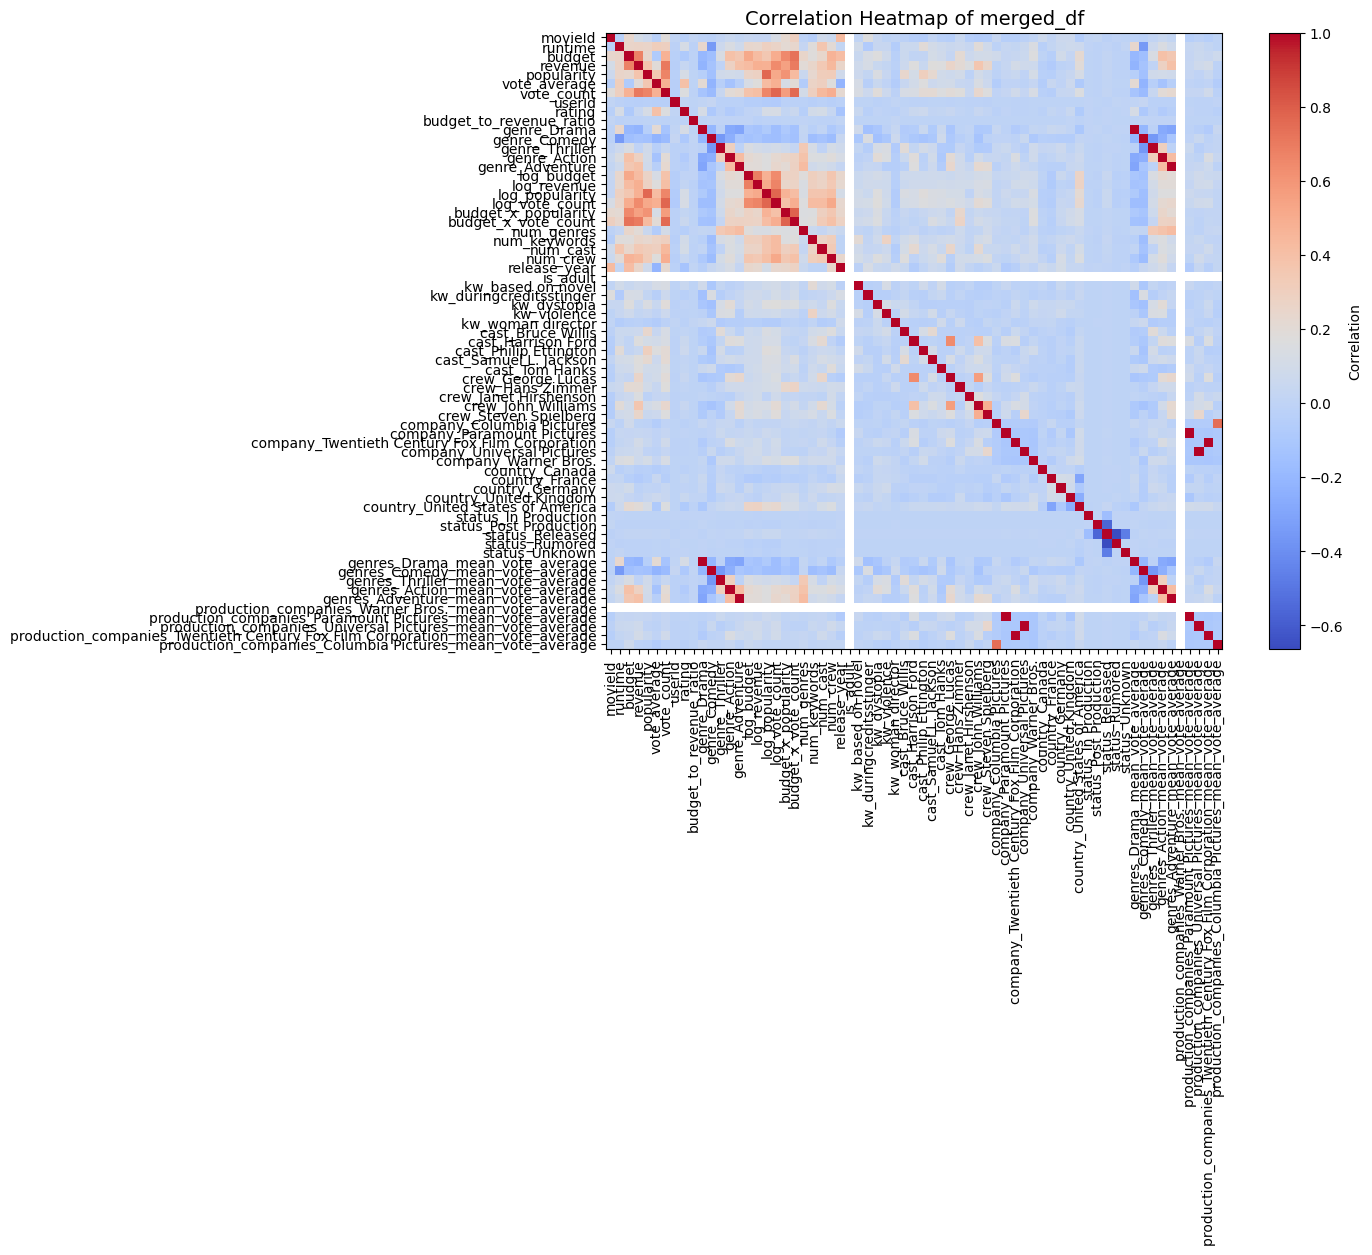

In [ ]:
import matplotlib.pyplot as plt

corr_matrix = merged_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of merged_df", fontsize=14)
plt.show()

# Modeling

## Model 1: Popularity Baseline

Implement a simple baseline that recommends the most popular movies globally using the IMDb weighted-rating (WR) formula.

In [ ]:
C = merged_df_with_svd['vote_average'].mean()
print(f"Mean rating across all movies (C): {C:.2f}")

m = merged_df_with_svd['vote_count'].quantile(0.90)
print(f"Minimum number of votes (m) for top list consideration (90th percentile): {m:.2f}")

qualified_movies = merged_df_with_svd[merged_df_with_svd['vote_count'] >= m].copy()
print(f"\nNumber of movies qualified for weighted rating calculation: {qualified_movies.shape[0]}")

def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

qualified_movies['weighted_rating'] = qualified_movies.apply(weighted_rating, axis=1)

popular_movies = qualified_movies.sort_values('weighted_rating', ascending=False)

popular_movies_unique = popular_movies.groupby('movieId').first().reset_index()

print("\nTop 10 Popular Movies based on Weighted Rating:")
display(popular_movies_unique[['title', 'vote_count', 'vote_average', 'weighted_rating']].head(10))

Mean rating across all movies (C): 6.87
Minimum number of votes (m) for top list consideration (90th percentile): 4183.00

Number of movies qualified for weighted rating calculation: 9972

Top 10 Popular Movies based on Weighted Rating:


,title,vote_count,vote_average,weighted_rating
0,Toy Story,5415.0,7.7,7.338731
1,Se7en,5915.0,8.1,7.590923
2,Star Wars,6778.0,8.1,7.631005
3,Leon: The Professional,4293.0,8.2,7.544153
4,Pulp Fiction,8670.0,8.3,7.834952
5,The Shawshank Redemption,8358.0,8.5,7.956674
6,Forrest Gump,8147.0,8.2,7.749152
7,The Lion King,5520.0,8.0,7.513310
8,Jurassic Park,4956.0,7.6,7.266358
9,Schindler's List,4436.0,8.3,7.606502


## Model 2: Content-Based (CB) Recommender

Using the item feature vectors, build user profiles. A user profile is the rating-weighted average of the vectors of the movies they have rated.

In [ ]:
unique_movies_reduced = merged_df_with_svd.drop_duplicates(subset=['movieId']).copy()
svd_features_unique = unique_movies_reduced.filter(like='svd_')

In [ ]:
unique_movies_reduced.shape

(8972, 140)

In [ ]:
svd_features_full = merged_df_with_svd.filter(like='svd_')
movie_id_to_index_full = pd.Series(merged_df_with_svd.index, index=merged_df_with_svd['movieId']).to_dict()

user_profiles = {}
for user_id in merged_df_with_svd['userId'].unique():
    user_ratings = merged_df_with_svd[merged_df_with_svd['userId'] == user_id][['movieId', 'rating']]
    profile = np.zeros(svd_features_full.shape[1])
    total_weight = 0
    for _, row in user_ratings.iterrows():
        movie_id = row['movieId']
        rating = row['rating']
        movie_index = movie_id_to_index_full.get(movie_id)
        if movie_index is not None:
            movie_features = svd_features_full.loc[movie_index].values
            profile += movie_features * rating
            total_weight += rating
    if total_weight > 0:
        profile /= total_weight
    user_profiles[user_id] = profile

print("Created user profiles for", len(user_profiles), "users.")

Created user profiles for 671 users.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_content_based_recommendations(user_id, merged_df_with_svd, unique_movies_reduced, user_profiles, top_n=10):
    if user_id not in user_profiles or np.all(user_profiles[user_id] == 0):
        print(f"User {user_id} is a cold-start user. Falling back to popularity baseline.")
        if 'popular_movies_unique' in globals():
            return popular_movies_unique[['title', 'vote_count', 'vote_average', 'weighted_rating', 'movieId']].head(top_n)
        else:
            print("Popularity baseline not available.")
            return pd.DataFrame()

    user_profile = user_profiles[user_id]

    svd_features_unique = unique_movies_reduced.filter(like='svd_')

    if user_profile.shape[0] != svd_features_unique.shape[1]:
      if user_profile.shape[0] < svd_features_unique.shape[1]:
        user_profile = np.pad(user_profile, (0, svd_features_unique.shape[1] - user_profile.shape[0]), 'constant')
      else:
        svd_features_unique = svd_features_unique.T.apply(lambda x: np.pad(x, (0, user_profile.shape[0] - x.shape[0]), 'constant'), axis=0).T


    cosine_sim = cosine_similarity(user_profile.reshape(1, -1), svd_features_unique)
    sim_scores = list(enumerate(cosine_sim[0]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    rated_movie_ids = merged_df_with_svd[merged_df_with_svd['userId'] == user_id]['movieId'].tolist()

    recommended_indices = [i for i, _ in sim_scores if unique_movies_reduced.iloc[i]['movieId'] not in rated_movie_ids]

    recommended_movies = unique_movies_reduced.iloc[recommended_indices][['movieId', 'title', 'vote_average', 'vote_count']].head(top_n)
    return recommended_movies.reset_index(drop=True)

sample_user_id = 1
content_based_recommendations = get_content_based_recommendations(
    sample_user_id, merged_df_with_svd, unique_movies_reduced, user_profiles, top_n=10
)

print(f"\nContent-Based Recommendations for User {sample_user_id}:")
display(content_based_recommendations)

cold_start_user_id = 9999
cold_start_recommendations = get_content_based_recommendations(
    cold_start_user_id, merged_df_with_svd, unique_movies_reduced, user_profiles, top_n=10
)

print(f"\nContent-Based Recommendations for Cold-Start User {cold_start_user_id}:")
display(cold_start_recommendations)


Content-Based Recommendations for User 1:


,movieId,title,vote_average,vote_count
0,6721,Once Upon a Time in China,7.4,99.0
1,158956,Kill Command,5.2,203.0
2,393,Street Fighter,4.1,330.0
3,4565,American Ninja,5.5,71.0
4,4442,The Last Dragon,6.4,71.0
5,59103,The Forbidden Kingdom,6.3,476.0
6,26012,Samurai III: Duel at Ganryu Island,7.4,24.0
7,79695,The Expendables,6.0,2977.0
8,42721,BloodRayne,3.6,120.0
9,704,The Quest,5.3,126.0


User 9999 is a cold-start user. Falling back to popularity baseline.

Content-Based Recommendations for Cold-Start User 9999:


,title,vote_count,vote_average,weighted_rating,movieId
0,Toy Story,5415.0,7.7,7.338731,1
1,Se7en,5915.0,8.1,7.590923,47
2,Star Wars,6778.0,8.1,7.631005,260
3,Leon: The Professional,4293.0,8.2,7.544153,293
4,Pulp Fiction,8670.0,8.3,7.834952,296
5,The Shawshank Redemption,8358.0,8.5,7.956674,318
6,Forrest Gump,8147.0,8.2,7.749152,356
7,The Lion King,5520.0,8.0,7.513310,364
8,Jurassic Park,4956.0,7.6,7.266358,480
9,Schindler's List,4436.0,8.3,7.606502,527


## Model 3: Collaborative Filtering (CF) Recommenders

Implement two CF approaches:

A neighbourhood-based model, such as user-user or item-item k-Nearest Neighbors (k-NN) with cosine or Pearson similarity.

In [ ]:
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import KNNBasic, SVD
from surprise import accuracy

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(merged_df_with_svd[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

sim_options = {
    'name': 'cosine',
    'user_based': True,
    'min_support': 1
}


knn_user = KNNBasic(sim_options=sim_options, k=15)
knn_user.fit(trainset)
predictions_knn = knn_user.test(testset)
rmse_knn = accuracy.rmse(predictions_knn)
print(f"User-based k-NN RMSE: {rmse_knn}")

svd_mf = SVD(n_factors=50, random_state=42)
svd_mf.fit(trainset)
predictions_svd = svd_mf.test(testset)
rmse_svd = accuracy.rmse(predictions_svd)
print(f"SVD (Matrix Factorization) RMSE: {rmse_svd}")


Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9948
User-based k-NN RMSE: 0.9947901650197927
RMSE: 0.8872
SVD (Matrix Factorization) RMSE: 0.8872490014511318


In [ ]:
def get_cf_recommendations(user_id, algo, merged_df_with_svd, top_n=10):
    rated_movie_ids = merged_df_with_svd[merged_df_with_svd['userId']==user_id]['movieId'].tolist()
    all_movie_ids = merged_df_with_svd['movieId'].unique()
    unseen_movies = [mid for mid in all_movie_ids if mid not in rated_movie_ids]

    preds = [(mid, algo.predict(user_id, mid).est) for mid in unseen_movies]
    preds.sort(key=lambda x: x[1], reverse=True)

    top_n_preds = preds[:top_n]
    top_n_df = pd.DataFrame(top_n_preds, columns=['movieId', 'predicted_rating'])

    top_n_df = top_n_df.merge(
        merged_df_with_svd[['movieId', 'title']].drop_duplicates(),
        on='movieId'
    )

    return top_n_df[['movieId', 'title', 'predicted_rating']]


In [ ]:
sample_user_id = 1

top_knn = get_cf_recommendations(sample_user_id, knn_user, merged_df_with_svd, top_n=10)
print(f"\nUser-based k-NN recommendations for User {sample_user_id}:")
display(top_knn)

top_svd = get_cf_recommendations(sample_user_id, svd_mf, merged_df_with_svd, top_n=10)
print(f"\nMatrix Factorization (SVD) recommendations for User {sample_user_id}:")
display(top_svd)



User-based k-NN recommendations for User 1:


,movieId,title,predicted_rating
0,183,Mute Witness,5
1,309,"Red Firecracker, Green Firecracker",5
2,702,Faces,5
3,759,Maya Lin: A Strong Clear Vision,5
4,764,Heavy,5
5,845,The Day the Sun Turned Cold,5
6,893,Mother Night,5
7,984,The Pompatus of Love,5
8,1056,Jude,5
9,1312,Female Perversions,5



Matrix Factorization (SVD) recommendations for User 1:


,movieId,title,predicted_rating
0,318,The Shawshank Redemption,3.686334
1,969,The African Queen,3.632321
2,3462,Modern Times,3.586802
3,858,The Godfather,3.580284
4,1228,Raging Bull,3.578779
5,1212,The Third Man,3.535737
6,898,The Philadelphia Story,3.528758
7,2571,The Matrix,3.518022
8,1221,The Godfather: Part II,3.511670
9,2542,"Lock, Stock and Two Smoking Barrels",3.511210


## Model 4: Hybrid Recommender

Combine the predictions from your CB and CF models.

The simplest way is a weighted blend: $s_{hyb} = \alpha \cdot s_{CF} + (1-\alpha) \cdot s_{CB}$.

You must tune the blending weight $\alpha$ on a validation set to find the optimal mix.

In [ ]:
from sklearn.model_selection import train_test_split
from surprise.model_selection import train_test_split as surprise_train_test_split

testset_df = pd.DataFrame(testset, columns=['userId', 'movieId', 'rating'])

print("Shape of the testset DataFrame (used for alpha tuning):", testset_df.shape)
display(testset_df.head())

def create_user_profile_from_ratings(user_ratings_df, unique_movies_reduced, movie_id_to_index):

    user_profiles = {}
    svd_features = unique_movies_reduced.filter(like='svd_')

    for user_id in user_ratings_df['userId'].unique():
        single_user_ratings = user_ratings_df[user_ratings_df['userId'] == user_id]
        user_profile = np.zeros(svd_features.shape[1])
        total_weight = 0

        for index, row in single_user_ratings.iterrows():
            movie_id = int(row['movieId'])
            rating = row['rating']

            movie_index = movie_id_to_index.get(movie_id)

            if movie_index is not None:
                movie_features = svd_features.loc[movie_index].values
                user_profile += movie_features * rating
                total_weight += rating

        if total_weight > 0:
            user_profile /= total_weight
        user_profiles[user_id] = user_profile

    return user_profiles

train_ratings_df = pd.DataFrame(trainset.all_ratings(), columns=['uid', 'iid', 'rating'])
train_ratings_df['userId'] = train_ratings_df['uid'].apply(lambda x: trainset.to_raw_uid(x))
train_ratings_df['movieId'] = train_ratings_df['iid'].apply(lambda x: trainset.to_raw_iid(x))
train_ratings_df = train_ratings_df[['userId', 'movieId', 'rating']]

movie_id_to_index = pd.Series(unique_movies_reduced.index, index=unique_movies_reduced['movieId']).to_dict()

user_profiles_train = create_user_profile_from_ratings(train_ratings_df, unique_movies_reduced, movie_id_to_index)

print(f"\nCreated user profiles using training data for {len(user_profiles_train)} users.")

Shape of the testset DataFrame (used for alpha tuning): (19769, 3)


,userId,movieId,rating
0,294,7,5.0
1,19,266,1.0
2,101,1610,4.0
3,357,223,4.0
4,418,4367,3.5



Created user profiles using training data for 671 users.


In [ ]:
def get_content_based_score(user_id, movie_id, merged_df_with_tfidf, unique_movies_reduced, user_profiles):
    if user_id not in user_profiles or np.all(user_profiles[user_id] == 0):
        return 0.0

    user_profile = user_profiles[user_id]

    movie_index_unique = unique_movies_reduced[unique_movies_reduced['movieId'] == movie_id].index
    if movie_index_unique.empty:
        return 0.0

    movie_features_unique = unique_movies_reduced.loc[movie_index_unique].filter(like='svd_').values

    cosine_sim_score = cosine_similarity(user_profile.reshape(1, -1), movie_features_unique.reshape(1, -1))[0][0]

    return cosine_sim_score

def hybrid_prediction(user_id, movie_id, alpha, cb_model, cf_model1, cf_model2, merged_df_with_tfidf, unique_movies_reduced, user_profiles):
    cb_score = cb_model(user_id, movie_id, merged_df_with_tfidf, unique_movies_reduced, user_profiles)
    try:
        cf1_pred = cf_model1.predict(str(user_id), str(movie_id)).est
    except Exception as e:
        cf1_pred = 0

    try:
        cf2_pred = cf_model2.predict(str(user_id), str(movie_id)).est
    except Exception as e:
        cf2_pred = 0

    cf_score = (cf1_pred + cf2_pred) / 2.0

    hybrid_score = alpha * cf_score + (1 - alpha) * cb_score

    return hybrid_score

sample_user_id_for_hybrid = 1
sample_movie_id_for_hybrid = 50

alpha_example = 0.5
predicted_rating = hybrid_prediction(
    sample_user_id_for_hybrid,
    sample_movie_id_for_hybrid,
    alpha_example,
    get_content_based_score,
    knn_user,
    svd_mf,
    merged_df_with_tfidf,
    unique_movies_reduced,
    user_profiles
)

print(f"\nHybrid predicted rating for User {sample_user_id_for_hybrid} and Movie {sample_movie_id_for_hybrid} (with alpha={alpha_example}): {predicted_rating:.2f}")


Hybrid predicted rating for User 1 and Movie 50 (with alpha=0.5): 1.71


Evaluating hybrid model with alpha = 0.00
RMSE for alpha = 0.00: 3.6300

Evaluating hybrid model with alpha = 0.50
RMSE for alpha = 0.50: 2.0312

Evaluating hybrid model with alpha = 1.00
RMSE for alpha = 1.00: 1.0547

Best alpha value: 1.00 with RMSE: 1.0547


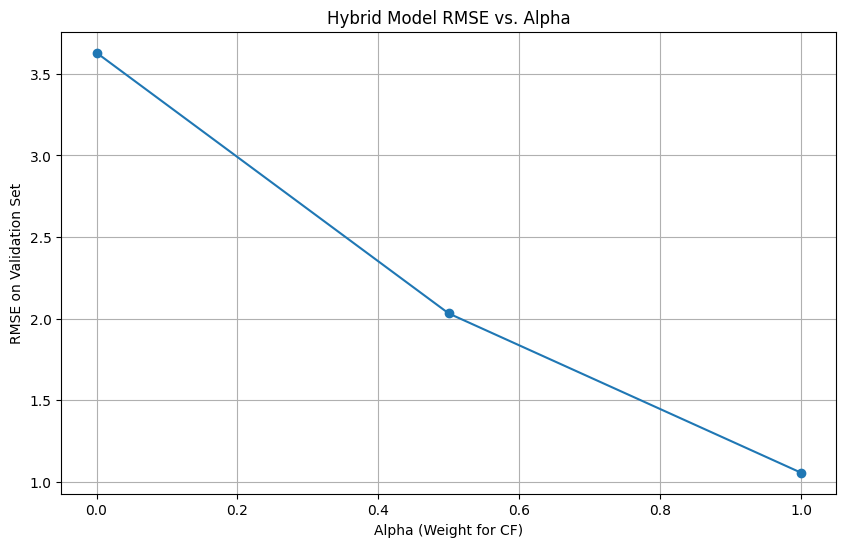

In [ ]:
from sklearn.metrics import mean_squared_error

alpha_values = np.arange(0, 1.01, 0.5)  # 0, 0.5, 1.0

rmse_scores = {}

for alpha in alpha_values:
    print(f"Evaluating hybrid model with alpha = {alpha:.2f}")
    predictions_hybrid = []
    actual_ratings = []

    for index, row in testset_df.iterrows():
        user_id = int(row['userId'])
        movie_id = int(row['movieId'])
        actual_rating = row['rating']

        predicted_rating = hybrid_prediction(
            user_id,
            movie_id,
            alpha,
            get_content_based_score,
            knn_user,
            svd_mf,
            merged_df_with_tfidf,
            unique_movies_reduced,
            user_profiles_train
        )

        predictions_hybrid.append(predicted_rating)
        actual_ratings.append(actual_rating)

    rmse = np.sqrt(mean_squared_error(actual_ratings, predictions_hybrid))
    rmse_scores[alpha] = rmse
    print(f"RMSE for alpha = {alpha:.2f}: {rmse:.4f}\n")

best_alpha = min(rmse_scores, key=rmse_scores.get)
min_rmse = rmse_scores[best_alpha]

print(f"Best alpha value: {best_alpha:.2f} with RMSE: {min_rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(list(rmse_scores.keys()), list(rmse_scores.values()), marker='o')
plt.xlabel("Alpha (Weight for CF)")
plt.ylabel("RMSE on Validation Set")
plt.title("Hybrid Model RMSE vs. Alpha")
plt.grid(True)
plt.show()

In [ ]:
from surprise.model_selection import GridSearchCV
from surprise import SVD
from surprise import Dataset, Reader
import pandas as pd
from surprise.model_selection import train_test_split
from surprise import accuracy

param_grid = {
    'n_factors': [50, 100, 150],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.05, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3) # Using 3-fold cross-validation

gs.fit(data)

print("Best RMSE score:", gs.best_score['rmse'])
print("Best parameters:", gs.best_params['rmse'])

svd_mf_tuned = SVD(**gs.best_params['rmse'])
svd_mf_tuned.fit(data.build_full_trainset())

predictions_tuned = svd_mf_tuned.test(testset)
rmse_tuned = accuracy.rmse(predictions_tuned)
print(f"Tuned Matrix Factorization (SVD) RMSE on testset: {rmse_tuned}")

Best RMSE score: 0.8888347206804088
Best parameters: {'n_factors': 100, 'lr_all': 0.01, 'reg_all': 0.1}
RMSE: 0.7501
Tuned Matrix Factorization (SVD) RMSE on testset: 0.7500697230805735
